# Laboratorio 4, Parte 2: preparación de datos geoespaciales para Machine Learning

Este notebook desarrolla las actividades **1 a 3** con los datos de Sentinel-2 de la Parte I.

> **Disponibilidad de datos.** En este repositorio no hay rasters de entrada; solo están disponibles las funciones de procesamiento de `mainlab4.py` y la serie temporal resumida en `outputs/actividad_4_serie_temporal_demo.csv`. Por ello, el notebook intenta primero cargar una tabla de píxeles o rasters reales y, si no existen, ejecuta un modo demostrativo reproducible. El modo demostrativo conserva las fechas y lagos oficiales, pero sus píxeles son sintéticos y no deben interpretarse como observaciones satelitales reales.

La estructura resultante es una fila por observación válida: coordenadas, fecha, lago, bandas, índices espectrales, clorofila-a estimada, índice de cianobacteria y variable respuesta binaria.

In [1]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown

ROOT = Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

try:
    from mainlab4 import OFFICIAL_DATES, LAKE_BBOXES
except ImportError:
    OFFICIAL_DATES = {}
    LAKE_BBOXES = {}

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 50)
RANDOM_STATE = 42
OUTPUT_DIR = ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)
print(f"Directorio de trabajo: {ROOT}")
print("Lagos oficiales:", list(LAKE_BBOXES) or ["Atitlan", "Amatitlan"])

Directorio de trabajo: d:\lab4data
Lagos oficiales: ['Atitlan', 'Amatitlan']


In [3]:
# 1.1-1.3 Construcción de una fila por píxel y limpieza
# Si se dispone de rasters, se recomienda exportar desde la Parte I una tabla CSV
# con estas columnas mínimas: lake, date, x, y, bandas B02...B12, NDVI, NDWI,
# FAI, NDCI, chlorophyll, water_mask, cloud_free.

PIXEL_TABLE_CANDIDATES = [
    ROOT / "inputs" / "pixel_table.csv",
    ROOT / "data" / "pixel_table.csv",
    ROOT / "outputs" / "pixel_table.csv",
]
real_pixel_table = next((p for p in PIXEL_TABLE_CANDIDATES if p.exists()), None)

if real_pixel_table is not None:
    df_raw = pd.read_csv(real_pixel_table)
    DATA_MODE = f"tabla real: {real_pixel_table}"
else:
    # Modo demostrativo: usa la serie temporal de la Parte I para parametrizar
    # píxeles sintéticos. Sirve para probar todo el flujo sin inventar fechas.
    series_path = OUTPUT_DIR / "actividad_4_serie_temporal_demo.csv"
    if not series_path.exists():
        raise FileNotFoundError("Falta outputs/actividad_4_serie_temporal_demo.csv")
    summary = pd.read_csv(series_path, parse_dates=["date"])
    rng = np.random.default_rng(RANDOM_STATE)
    rows = []
    for record in summary.itertuples(index=False):
        bbox = LAKE_BBOXES.get(record.lake, {
            "west": -91.3, "east": -91.1, "south": 14.6, "north": 14.75
        })
        n_pixels = 180
        # Puntos dentro de un óvalo, usado únicamente como máscara demostrativa.
        u = rng.uniform(-1, 1, n_pixels)
        v = rng.uniform(-1, 1, n_pixels)
        inside = (u / 0.92) ** 2 + (v / 0.78) ** 2 < 1
        x = (bbox["west"] + bbox["east"]) / 2 + u * (bbox["east"] - bbox["west"]) / 2
        y = (bbox["south"] + bbox["north"]) / 2 + v * (bbox["north"] - bbox["south"]) / 2
        target_index = np.clip(
            rng.normal(record.mean_cyano_index, max(8, record.mean_cyano_index * 0.22), n_pixels),
            0.05, None
        )
        # Reflectancias plausibles y correlacionadas suavemente con el estado del agua.
        bloom = np.clip(target_index / 180, 0, 1)
        B04 = np.clip(0.035 + 0.020 * bloom + rng.normal(0, .004, n_pixels), .005, .25)
        B05 = np.clip(0.045 + 0.045 * bloom + rng.normal(0, .005, n_pixels), .005, .35)
        B02 = np.clip(0.025 + 0.010 * bloom + rng.normal(0, .003, n_pixels), .003, .25)
        B03 = np.clip(0.055 + 0.030 * bloom + rng.normal(0, .005, n_pixels), .005, .40)
        B07 = np.clip(0.075 + 0.070 * bloom + rng.normal(0, .006, n_pixels), .005, .50)
        B08 = np.clip(0.105 + 0.035 * bloom + rng.normal(0, .006, n_pixels), .005, .60)
        B8A = np.clip(0.090 + 0.040 * bloom + rng.normal(0, .006, n_pixels), .005, .60)
        B11 = np.clip(0.018 + rng.normal(0, .003, n_pixels), .002, .20)
        B12 = np.clip(0.012 + rng.normal(0, .002, n_pixels), .002, .20)
        for i in range(n_pixels):
            rows.append({
                "lake": record.lake, "date": record.date, "x": x[i], "y": y[i],
                "B02": B02[i], "B03": B03[i], "B04": B04[i], "B05": B05[i],
                "B07": B07[i], "B08": B08[i], "B8A": B8A[i], "B11": B11[i], "B12": B12[i],
                "NDVI": (B08[i] - B04[i]) / (B08[i] + B04[i]),
                "NDWI": (B03[i] - B08[i]) / (B03[i] + B08[i]),
                "FAI": B07[i] - B04[i] - (B8A[i] - B04[i]) * (783 - 665) / (865 - 665),
                "NDCI": (B05[i] - B04[i]) / (B05[i] + B04[i]),
                "chlorophyll": target_index[i], "cyano_index": target_index[i],
                "water_mask": bool(inside[i]), "cloud_free": True,
            })
    df_raw = pd.DataFrame(rows)
    DATA_MODE = "demostrativo parametrizado por la serie temporal de la Parte I"

print("Modo de datos:", DATA_MODE)
required = ["lake", "date", "x", "y", "water_mask", "cloud_free", "cyano_index"]
missing_required = sorted(set(required) - set(df_raw.columns))
if missing_required:
    raise ValueError(f"La tabla de píxeles no contiene columnas requeridas: {missing_required}")

# Normaliza tipos y elimina duplicados, fuera de agua, nubes y valores no finitos.
df_raw["date"] = pd.to_datetime(df_raw["date"])
if "cloud_free" not in df_raw:
    df_raw["cloud_free"] = True
band_columns = [c for c in ["B02", "B03", "B04", "B05", "B07", "B08", "B8A", "B11", "B12"] if c in df_raw]
index_columns = [c for c in ["NDVI", "NDWI", "FAI", "NDCI", "chlorophyll", "cyano_index"] if c in df_raw]
numeric_columns = ["x", "y"] + band_columns + index_columns
for column in numeric_columns:
    df_raw[column] = pd.to_numeric(df_raw[column], errors="coerce")
finite_mask = np.isfinite(df_raw[numeric_columns]).all(axis=1)
valid_mask = df_raw["water_mask"].astype(bool) & df_raw["cloud_free"].astype(bool) & finite_mask
df = df_raw.loc[valid_mask].drop_duplicates(subset=["lake", "date", "x", "y"]).reset_index(drop=True)
print(f"Filas iniciales: {len(df_raw):,}; filas válidas: {len(df):,}; eliminadas: {len(df_raw) - len(df):,}")
assert len(df) > 0, "La limpieza dejó el dataset vacío"

Modo de datos: demostrativo parametrizado por la serie temporal de la Parte I
Filas iniciales: 3,960; filas válidas: 2,226; eliminadas: 1,734


In [4]:
# 1.4 Auditoría del conjunto de datos
print(f"Total de observaciones válidas: {len(df):,}")
print("\nObservaciones por lago:")
display(df["lake"].value_counts().rename("n_observaciones").to_frame())
print("\nObservaciones por fecha:")
display(df.groupby("date").size().rename("n_observaciones").to_frame())

schema = pd.DataFrame({
    "variable": df.columns,
    "tipo": [str(df[c].dtype) for c in df.columns],
    "n_unicos": [df[c].nunique(dropna=True) for c in df.columns],
    "faltantes_%": [100 * df[c].isna().mean() for c in df.columns],
})
display(schema)

missing_report = (df.isna().mean() * 100).sort_values(ascending=False).rename("faltantes_%").to_frame()
display(missing_report)
assert missing_report["faltantes_%"].max() == 0, "La tabla limpia no debería tener faltantes en modo demostrativo"

# Exporta la tabla lista para ML; se conserva fecha y posición geográfica.
df.to_csv(OUTPUT_DIR / "actividad_1_dataset_ml.csv", index=False)
print("Tabla exportada en outputs/actividad_1_dataset_ml.csv")

Total de observaciones válidas: 2,226

Observaciones por lago:


,n_observaciones
lake,
Amatitlan,1145
Atitlan,1081



Observaciones por fecha:


,n_observaciones
date,
2025-01-18,98
2025-01-28,106
2025-04-13,92
2025-04-15,99
2025-04-28,105
2025-05-13,102
2025-07-17,99
2025-11-21,95
2025-11-24,116


,variable,tipo,n_unicos,faltantes_%
0,lake,object,2,0.0
1,date,datetime64[ns],20,0.0
2,x,float64,2226,0.0
3,y,float64,2226,0.0
4,B02,float64,2226,0.0
5,B03,float64,2226,0.0
6,B04,float64,2226,0.0
7,B05,float64,2226,0.0
8,B07,float64,2226,0.0
9,B08,float64,2226,0.0


,faltantes_%
lake,0.0
date,0.0
x,0.0
y,0.0
B02,0.0
B03,0.0
B04,0.0
B05,0.0
B07,0.0
B08,0.0


Tabla exportada en outputs/actividad_1_dataset_ml.csv


## 1.5-1.6. Análisis exploratorio y decisiones de limpieza

Las variables espectrales se mantienen como reflectancia (0 a 1). NDVI, NDWI, FAI y NDCI son índices adimensionales; `cyano_index`/`chlorophyll` está expresado en ug/L según la calibración del script de la Parte I. La máscara de agua evita mezclar píxeles terrestres con agua, y `cloud_free` evita contaminación por nubes. No se imputan valores faltantes: para este problema, imputar un píxel sin señal física sería menos defendible que excluirlo.

Las coordenadas se conservan para trazabilidad y para análisis espacial posterior, pero no se usan automáticamente como predictores: podrían hacer que el modelo memorice la geografía de los lagos en vez de aprender una señal espectral generalizable.

,count,mean,std,min,1%,25%,50%,75%,99%,max
B02,2226.0,0.029295,0.003807,0.016058,0.020808,0.026798,0.029181,0.031847,0.038321,0.041442
B03,2226.0,0.067991,0.008564,0.045391,0.050463,0.062033,0.067521,0.073402,0.089412,0.098458
B04,2226.0,0.043762,0.006113,0.025060,0.030994,0.039545,0.043232,0.047877,0.058387,0.066654
B05,2226.0,0.064824,0.011705,0.037249,0.042640,0.056240,0.063672,0.072032,0.094047,0.102960
B07,2226.0,0.105695,0.017514,0.065486,0.074076,0.092087,0.103718,0.116138,0.146843,0.161741
B08,2226.0,0.120354,0.010247,0.093185,0.099671,0.113241,0.119269,0.127040,0.144157,0.153701
B8A,2226.0,0.107664,0.011305,0.075132,0.085886,0.099370,0.106709,0.114805,0.135008,0.143816
B11,2226.0,0.018097,0.003050,0.006900,0.011183,0.016032,0.018032,0.020122,0.025077,0.027579
B12,2226.0,0.012080,0.002057,0.005093,0.007376,0.010689,0.012062,0.013473,0.016821,0.020654
NDVI,2226.0,0.467992,0.042847,0.304689,0.372004,0.438843,0.466515,0.496558,0.571493,0.602458


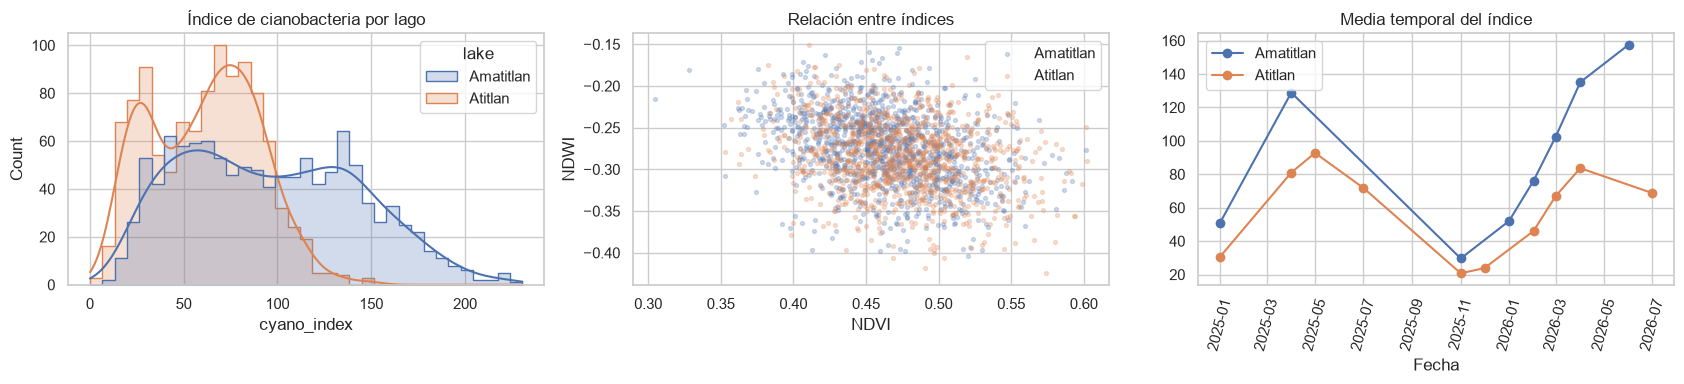

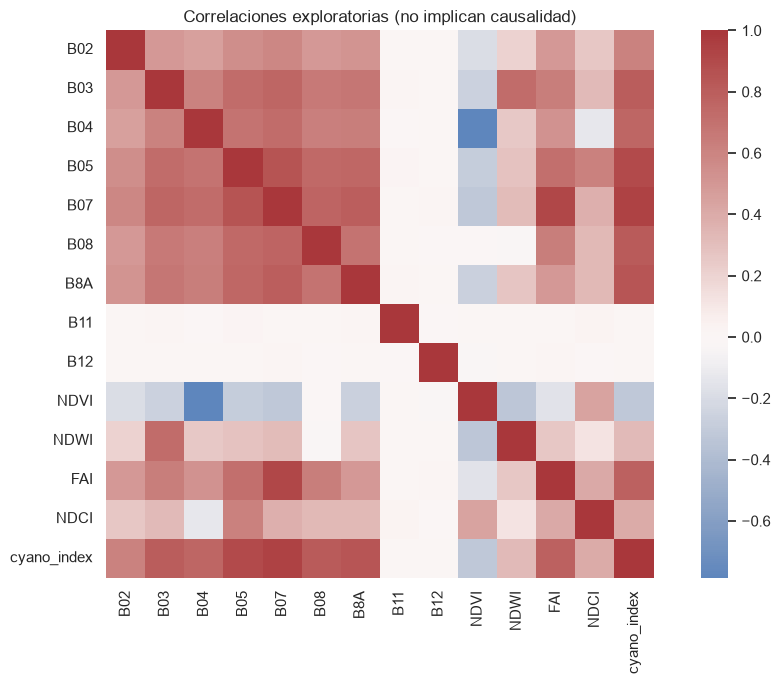

In [10]:
# Distribuciones, relaciones y evolución temporal
eda_columns = [c for c in ["B02", "B03", "B04", "B05", "B07", "B08", "B8A", "B11", "B12", "NDVI", "NDWI", "FAI", "NDCI", "cyano_index"] if c in df]
display(df[eda_columns].describe(percentiles=[.01, .25, .5, .75, .99]).T)

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
sns.histplot(data=df, x="cyano_index", hue="lake", bins=35, kde=True, ax=axes[0], element="step")
axes[0].set_title("Índice de cianobacteria por lago")
for lake, group in df.groupby("lake"):
    axes[1].scatter(group["NDVI"], group["NDWI"], s=8, alpha=.25, label=lake)
axes[1].set(xlabel="NDVI", ylabel="NDWI", title="Relación entre índices")
axes[1].legend()
monthly = (df.assign(date_month=df["date"].dt.to_period("M"))
           .groupby(["lake", "date_month"], as_index=False)["cyano_index"].mean()
           .sort_values(["date_month", "lake"]))
for lake, group in monthly.groupby("lake", sort=False):
    axes[2].plot(group["date_month"].dt.to_timestamp(), group["cyano_index"], marker="o", label=lake)
axes[2].set_title("Media temporal del índice")
axes[2].set_xlabel("Fecha")
axes[2].tick_params(axis="x", rotation=75)
axes[2].legend()
plt.tight_layout()
plt.show()

corr_cols = [c for c in ["B02", "B03", "B04", "B05", "B07", "B08", "B8A", "B11", "B12", "NDVI", "NDWI", "FAI", "NDCI", "cyano_index"] if c in df]
plt.figure(figsize=(10, 7))
sns.heatmap(df[corr_cols].corr(numeric_only=True), cmap="vlag", center=0, square=True)
plt.title("Correlaciones exploratorias (no implican causalidad)")
plt.tight_layout()
plt.show()

## 2. Construcción de la variable respuesta

Se define `high_cyano = 1` cuando `cyano_index >= 50 ug/L` y `0` en otro caso. El valor se usa como **umbral operativo de cribado**, no como una frontera universal para todas las especies: la relación NDCI-clorofila del script debe validarse con muestras in situ.

La justificación ambiental es que la clasificación trófica de OECD considera concentraciones de clorofila-a superiores a aproximadamente 25 ug/L como indicadoras de condiciones eutróficas/hipereutróficas, asociadas con mayor probabilidad de floraciones; 50 ug/L es un criterio más conservador para marcar biomasa algal claramente elevada. Para gestión sanitaria, la OMS recomienda combinar clorofila, biovolumen/células y toxinas, porque la clorofila por sí sola no identifica toxicidad ni composición taxonómica.

Referencias:

- OECD (1982). *Eutrophication of Waters: Monitoring, Assessment and Control*. OECD, Paris. https://doi.org/10.1787/9789264077980-en
- WHO (2021). *Guidelines on recreational water quality: Volume 1, coastal and fresh waters*. World Health Organization. https://www.who.int/publications/i/item/9789240031302
- Mishra, S. et al. (2019). *Applicability of Sentinel-2 satellite data for monitoring chlorophyll-a in inland waters*. Remote Sensing of Environment, 232, 111354. https://doi.org/10.1016/j.rse.2019.111354

El umbral debe revisarse mediante análisis de sensibilidad y validación de campo; cambiarlo después de mirar los predictores produciría una decisión circular.

Umbral operativo: 50.0 ug/L
Distribución global:


,n,porcentaje
high_cyano,,
baja/ausencia,631,28.34681
alta,1595,71.65319


Por lago (%):


high_cyano,baja_%,alta_%
lake,,
Amatitlan,20.436681,79.563319
Atitlan,36.725254,63.274746


Por fecha (%):


high_cyano,baja_%,alta_%
date,,
2025-01-18,96.938776,3.061224
2025-01-28,49.056604,50.943396
2025-04-13,3.260870,96.739130
2025-04-15,0.000000,100.000000
2025-04-28,0.952381,99.047619
2025-05-13,3.921569,96.078431
2025-07-17,9.090909,90.909091
2025-11-21,100.000000,0.000000
2025-11-24,100.000000,0.000000


Razón de desbalance mayor/menor: 2.53
Existe desbalance relevante: accuracy puede ocultar errores de la clase minoritaria; se deben reportar recall, precision, F1, ROC-AUC y, preferiblemente, PR-AUC.


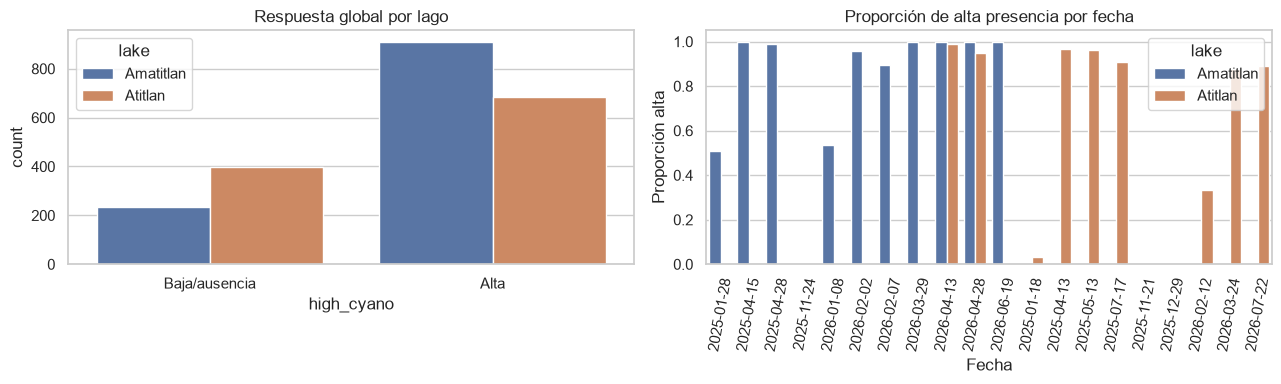

Variables excluidas por fuga directa o indirecta: ['cyano_index', 'chlorophyll', 'NDCI', 'B04', 'B05', 'high_cyano']


In [7]:
CYANO_THRESHOLD = 50.0
df["high_cyano"] = (df["cyano_index"] >= CYANO_THRESHOLD).astype("int8")

print(f"Umbral operativo: {CYANO_THRESHOLD:.1f} ug/L")
print("Distribución global:")
global_class = df["high_cyano"].value_counts().sort_index().rename(index={0: "baja/ausencia", 1: "alta"})
display(pd.DataFrame({"n": global_class, "porcentaje": 100 * global_class / len(df)}))

by_lake = pd.crosstab(df["lake"], df["high_cyano"], normalize="index").mul(100).rename(columns={0: "baja_%", 1: "alta_%"})
by_date = pd.crosstab(df["date"], df["high_cyano"], normalize="index").mul(100).rename(columns={0: "baja_%", 1: "alta_%"})
print("Por lago (%):")
display(by_lake)
print("Por fecha (%):")
display(by_date)

class_counts = df["high_cyano"].value_counts().sort_index()
imbalance_ratio = class_counts.max() / class_counts.min()
print(f"Razón de desbalance mayor/menor: {imbalance_ratio:.2f}")
if imbalance_ratio >= 1.5:
    print("Existe desbalance relevante: accuracy puede ocultar errores de la clase minoritaria; se deben reportar recall, precision, F1, ROC-AUC y, preferiblemente, PR-AUC.")
else:
    print("No se observa desbalance severo con este umbral; aun así se deben conservar métricas por clase.")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.countplot(data=df, x="high_cyano", hue="lake", ax=axes[0])
axes[0].set_xticks([0, 1], ["Baja/ausencia", "Alta"])
axes[0].set_title("Respuesta global por lago")
plot_date = df.assign(date_label=df["date"].dt.strftime("%Y-%m-%d"))
sns.barplot(data=plot_date, x="date_label", y="high_cyano", hue="lake", errorbar=None, ax=axes[1])
axes[1].set_ylabel("Proporción alta")
axes[1].set_xlabel("Fecha")
axes[1].tick_params(axis="x", rotation=80)
axes[1].set_title("Proporción de alta presencia por fecha")
plt.tight_layout()
plt.show()

# La respuesta se construyó desde cyano_index, que depende de NDCI,
# y NDCI usa directamente B04 y B05.
leakage_columns = ["cyano_index", "chlorophyll", "NDCI", "B04", "B05", "high_cyano"]
print("Variables excluidas por fuga directa o indirecta:", [c for c in leakage_columns if c in df.columns])

## 3. Selección y construcción de variables predictoras

El conjunto base será `B02`, `B03`, `B07`, `B08`, `B8A`, `B11`, `B12`, `NDVI` y `NDWI`.

- **B02/B03/B07/B08/B8A/B11/B12:** reflectancias azul, verde, borde rojo, NIR y SWIR. La materia algal y la materia orgánica modifican la reflectancia en visible y NIR; SWIR ayuda a distinguir agua de suelo, vegetación y píxeles contaminados.
- **NDVI:** contraste NIR-rojo; ayuda a detectar vegetación emergente o píxeles mixtos que deben distinguirse de una señal algal.
- **NDWI:** contraste verde-NIR; caracteriza el estado de agua y puede separar agua abierta de vegetación/suelo.
- **Mes del año codificado cíclicamente:** representa estacionalidad sin imponer que diciembre y enero estén lejos; es una característica temporal, no una medición causal.
- **Promedio de borde rojo (`rededge_mean`) y razón NIR-verde (`nir_green_ratio`):** ingeniería de características que resume la respuesta espectral asociada a biomasa y turbidez.

No se utilizan coordenadas ni `lake` en el conjunto base de predictores: se conservan para trazabilidad, estratificación y validación espacial, pero incluirlos podría memorizar diferencias entre lagos y dar una estimación demasiado optimista.

In [8]:
# 3.1-3.3 Variables finales para futuros modelos
predictor_columns = [c for c in ["B02", "B03", "B07", "B08", "B8A", "B11", "B12", "NDVI", "NDWI"] if c in df.columns]
df["month_sin"] = np.sin(2 * np.pi * df["date"].dt.month / 12)
df["month_cos"] = np.cos(2 * np.pi * df["date"].dt.month / 12)
if {"B07", "B8A"}.issubset(df.columns):
    df["rededge_mean"] = df[["B07", "B8A"]].mean(axis=1)
    predictor_columns.append("rededge_mean")
if {"B08", "B03"}.issubset(df.columns):
    df["nir_green_ratio"] = df["B08"] / df["B03"].replace(0, np.nan)
    predictor_columns.append("nir_green_ratio")
predictor_columns.extend(["month_sin", "month_cos"])

predictor_audit = pd.DataFrame({
    "predictor": predictor_columns,
    "tipo": [str(df[c].dtype) for c in predictor_columns],
    "faltantes_%": [100 * df[c].isna().mean() for c in predictor_columns],
})
display(predictor_audit)
print("Predictores finales:", predictor_columns)
print("Excluidos por fuga:", [c for c in leakage_columns if c in df.columns])

assert not set(predictor_columns) & set(leakage_columns), "Hay fuga de información en los predictores"
assert df[predictor_columns].notna().all().all(), "Hay faltantes en predictores"
df.to_csv(OUTPUT_DIR / "actividad_1_dataset_ml_con_predictores.csv", index=False)
print("Dataset final exportado en outputs/actividad_1_dataset_ml_con_predictores.csv")

,predictor,tipo,faltantes_%
0,B02,float64,0.0
1,B03,float64,0.0
2,B07,float64,0.0
3,B08,float64,0.0
4,B8A,float64,0.0
5,B11,float64,0.0
6,B12,float64,0.0
7,NDVI,float64,0.0
8,NDWI,float64,0.0
9,rededge_mean,float64,0.0


Predictores finales: ['B02', 'B03', 'B07', 'B08', 'B8A', 'B11', 'B12', 'NDVI', 'NDWI', 'rededge_mean', 'nir_green_ratio', 'month_sin', 'month_cos']
Excluidos por fuga: ['cyano_index', 'chlorophyll', 'NDCI', 'B04', 'B05', 'high_cyano']
Dataset final exportado en outputs/actividad_1_dataset_ml_con_predictores.csv
